# Task 1 : Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Task 2 : Importing Dataset

In [2]:
df = pd.read_csv('Online Retail.csv' , encoding = 'unicode_escape')

# Task 3 : Exploring Dataset

In [3]:
# Finding the number of columns and rows

print(f'Dataset : {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset : 541,909 rows x 8 columns


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.sample()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
20978,538071,22383,LUNCH BAG SUKI DESIGN,2,09-12-2010 14:09,4.21,NaN,United Kingdom


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Exploring the datatypes of columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Task 4 : Data Cleaning

In [8]:
# finding null values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# finding duplicate entries

df.duplicated().sum()

np.int64(5268)

In [10]:
# making a copy of our dataset

temp = df.copy()

In [11]:
temp.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [12]:
# removing duplicate values

temp.drop_duplicates(inplace=True)

In [13]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [14]:
# removing null values on the basis of CustomerID column

temp.dropna(subset = ['CustomerID'], inplace=True)

In [15]:
temp.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
print(f'Total number of txn after data cleaning = {temp.shape[0]:,}')

Total number of txn after data cleaning = 401,604


# Task 5 : Statistical Analysis

In [17]:
# checking for outliers in Quantity column

temp['Quantity'].value_counts().sort_index()

Quantity
-80995    1
-74215    1
-9360     1
-3114     1
-2000     1
         ..
 4300     1
 4800     1
 12540    1
 74215    1
 80995    1
Name: count, Length: 436, dtype: int64

In [18]:
# defining q1, q2, IQR, lf, uf

q1 = np.percentile(temp['Quantity'],25)
q3 = np.percentile(temp['Quantity'],75)
IQR = q3-q1
lf = q1-1.5*IQR
uf = q3+1.5*IQR

In [19]:
print(f'Interquartile range(IQR) = {IQR}\n Lower Fence(lf) = {lf}\n Upper Fence = {uf}')

Interquartile range(IQR) = 10.0
 Lower Fence(lf) = -13.0
 Upper Fence = 27.0


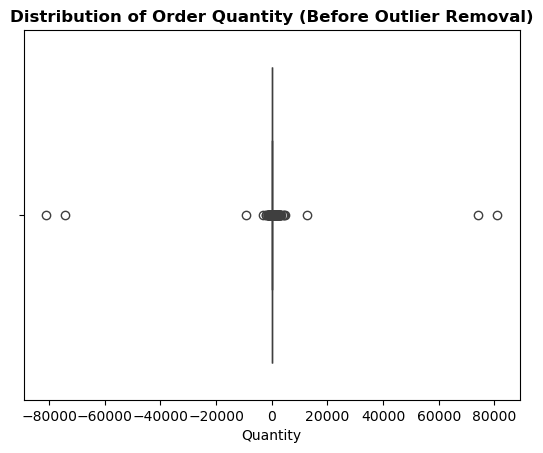

In [20]:
# boxplot for detecting outliers 

sns.boxplot(data = temp, x = 'Quantity')
plt.title('Distribution of Order Quantity (Before Outlier Removal)', fontsize = 12, fontweight = 'bold')
plt.show()

In [21]:
# removing outliers

temp = temp[(temp['Quantity'] >= lf) & (temp['Quantity'] <= uf)]

In [22]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374958 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    374958 non-null  object 
 1   StockCode    374958 non-null  object 
 2   Description  374958 non-null  object 
 3   Quantity     374958 non-null  int64  
 4   InvoiceDate  374958 non-null  object 
 5   UnitPrice    374958 non-null  float64
 6   CustomerID   374958 non-null  float64
 7   Country      374958 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 25.7+ MB


In [23]:
temp.describe()

,Quantity,UnitPrice,CustomerID
count,374958.000000,374958.000000,374958.000000
mean,6.880915,3.614262,15296.014255
std,6.776924,72.189462,1712.757792
min,-13.000000,0.000000,12347.000000
25%,2.000000,1.250000,13969.000000
50%,4.000000,1.950000,15159.000000
75%,12.000000,3.750000,16800.000000
max,27.000000,38970.000000,18287.000000


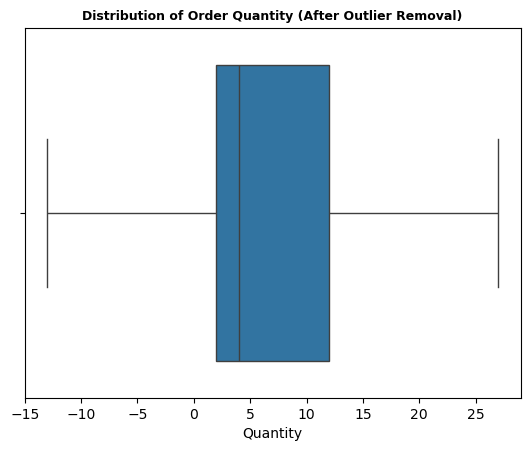

In [24]:
# boxplot after removing outliers

sns.boxplot(data = temp, x = 'Quantity')
plt.title('Distribution of Order Quantity (After Outlier Removal)', fontsize = 9, fontweight = 'bold')
plt.show()

In [25]:
temp['Quantity'].value_counts().sort_index()

Quantity
-13       16
-12      517
-11       45
-10      164
-9        47
-8       143
-7        81
-6       468
-5       186
-4       454
-3       576
-2      1326
-1      3828
 1     69605
 2     57425
 3     26817
 4     32093
 5      8100
 6     37480
 7      1296
 8     11594
 9      1169
 10    21161
 11      341
 12    59828
 13      200
 14      237
 15      447
 16     3945
 17       73
 18     1556
 19       71
 20     4761
 21       65
 22       60
 23       30
 24    23694
 25     4976
 26       36
 27       47
Name: count, dtype: int64

In [26]:
temp['Quantity'].value_counts().sort_values()

Quantity
-13       16
 23       30
 26       36
-11       45
 27       47
-9        47
 22       60
 21       65
 19       71
 17       73
-7        81
-8       143
-10      164
-5       186
 13      200
 14      237
 11      341
 15      447
-4       454
-6       468
-12      517
-3       576
 9      1169
 7      1296
-2      1326
 18     1556
-1      3828
 16     3945
 20     4761
 25     4976
 5      8100
 8     11594
 10    21161
 24    23694
 3     26817
 4     32093
 6     37480
 2     57425
 12    59828
 1     69605
Name: count, dtype: int64

# Task 6 : Exploratory Data Analysis

In [27]:
# Feature Engineering
# 1. Adding TotalAmount Column

temp['TotalAmount'] = temp['UnitPrice']*temp['Quantity']

In [28]:
# 2. Adding Status column

temp['Status'] = np.where(temp['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Success')

In [29]:
# 3. Changing the datatype of CustomerID

temp['CustomerID'] = temp['CustomerID'].astype('str')

In [30]:
# 4 Changing the datatype of InvoiceDate

temp['InvoiceDate'] = pd.to_datetime(temp['InvoiceDate'], format='%d-%m-%Y %H:%M')

In [31]:
temp['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 374958, dtype: datetime64[ns]

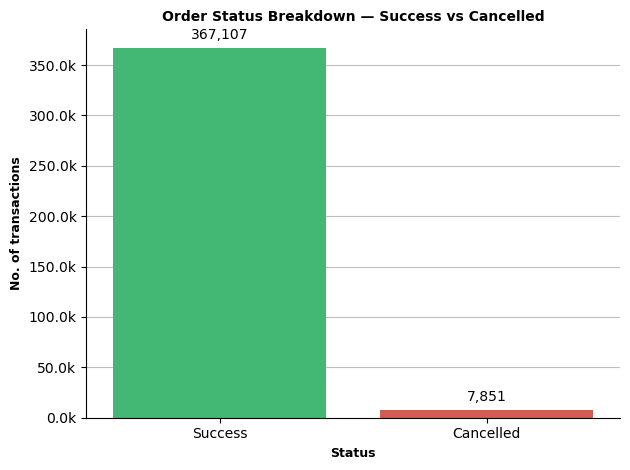

In [32]:
# Order status

ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)

b4 = sns.countplot(data = temp, x = 'Status', ax = ax, palette = {'Success': '#2ecc71', 'Cancelled': '#e74c3c'})
plt.title('Order Status Breakdown — Success vs Cancelled', fontsize = 10, fontweight = 'bold')
plt.xlabel('Status', fontsize = 9, fontweight = 'bold')
plt.ylabel('No. of transactions', fontsize = 9, fontweight = 'bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:,.1f}k'))
for container in b4.containers:
    b4.bar_label(container, fmt = '{:,.0f}', padding = 4, fontsize = 10)

plt.tight_layout()
plt.show()

* ***Total transactions** = **374,958***
* ***Success** orders = **367,107***
* ***Cancelled** orders = **7,851***
* ***Success orders clearly dominates** by more than **46 times**, which shows **customer satisfaction and fullfilment** of this platform*

In [33]:
print(f'Total number of unique countries = {temp['Country'].nunique()}')

Total number of unique countries = 37


In [34]:
# Country-wise Revenue, Avg Spend & Total Items Sold

country_info = temp.groupby('Country').agg(total_rev = ('TotalAmount', 'sum'), 
                                           avg_spend = ('TotalAmount', 'mean'),
                                           total_item = ('Quantity', 'sum')).reset_index()

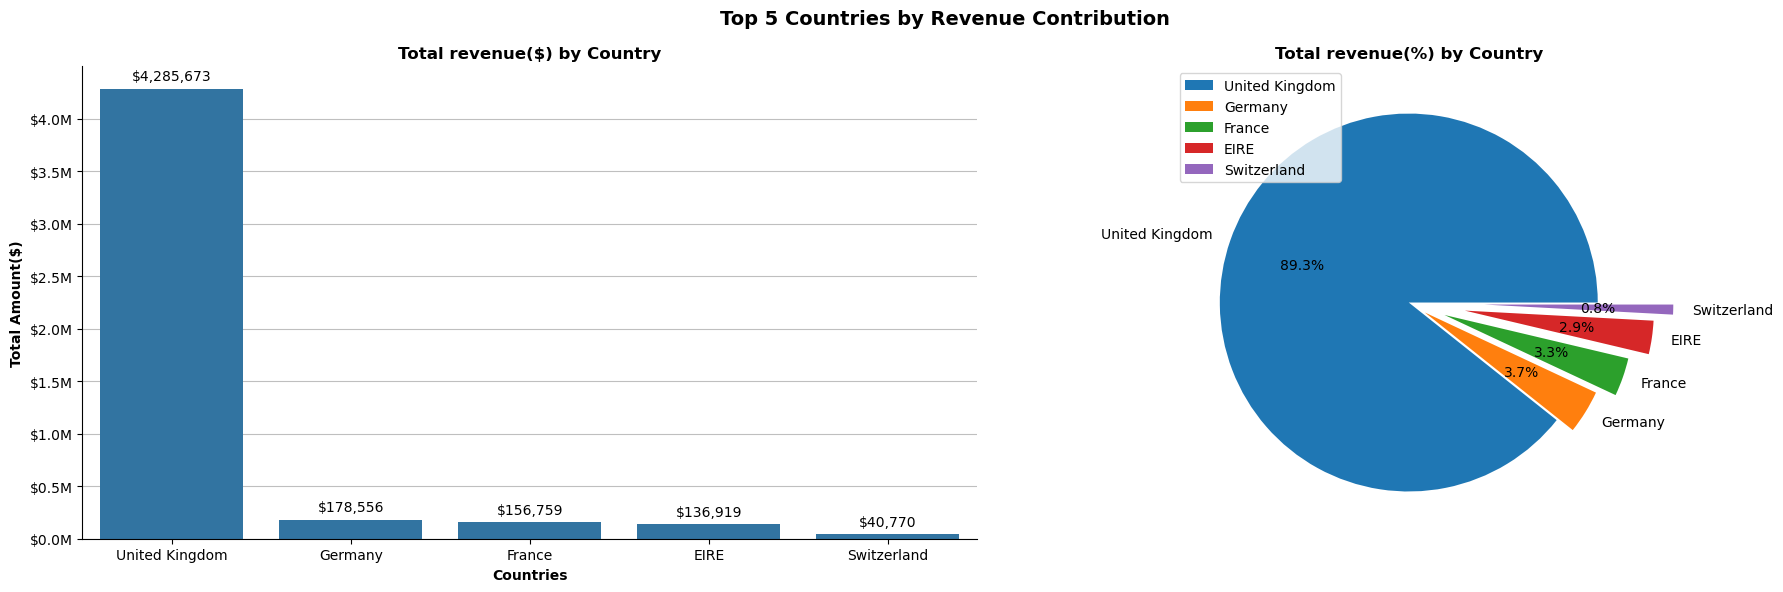

In [35]:
# top 5 countries in revenue

top5_countries_rev = country_info.sort_values('total_rev', ascending = False).head(5)
top5_countries_rev['rev_pct'] = 100 * top5_countries_rev['total_rev']/top5_countries_rev['total_rev'].sum()

fig, ax = plt.subplots(1, 2, figsize = (19, 6))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

# bar graph
b3 = sns.barplot(data = top5_countries_rev, x = 'Country', y = 'total_rev', ax = ax[0])
ax[0].set_title('Total revenue($) by Country', fontsize = 12, fontweight = 'bold')
ax[0].set_ylabel('Total Amount($)', fontsize = 10, fontweight = 'bold')
ax[0].set_xlabel('Countries', fontsize = 10, fontweight = 'bold')
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:,.1f}M'))
for bars in b3.containers:
    b3.bar_label(bars, labels = [f'${v:,.0f}' for v in top5_countries_rev['total_rev']], padding = 4, fontsize = 10)
    
# pie chart
ax[1].pie(top5_countries_rev['total_rev'], labels = top5_countries_rev['Country'], autopct = '%0.1f%%', explode = [0, 0.1, 0.2, 0.3, 0.4])
ax[1].set_title('Total revenue(%) by Country', fontsize = 12, fontweight = 'bold')
ax[1].legend()

plt.suptitle('Top 5 Countries by Revenue Contribution', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

* ***UK** alone **contributes** **89.3%(4.28M USD)** of **total revenue**, showing absolute dominance.*
* *The **rest of the countries** has **massive difference** in **revenue from UK**, shows the **extreme single market dependency.***
* *If **UK demand dips, revenue collapses, urgent diversification needed.***

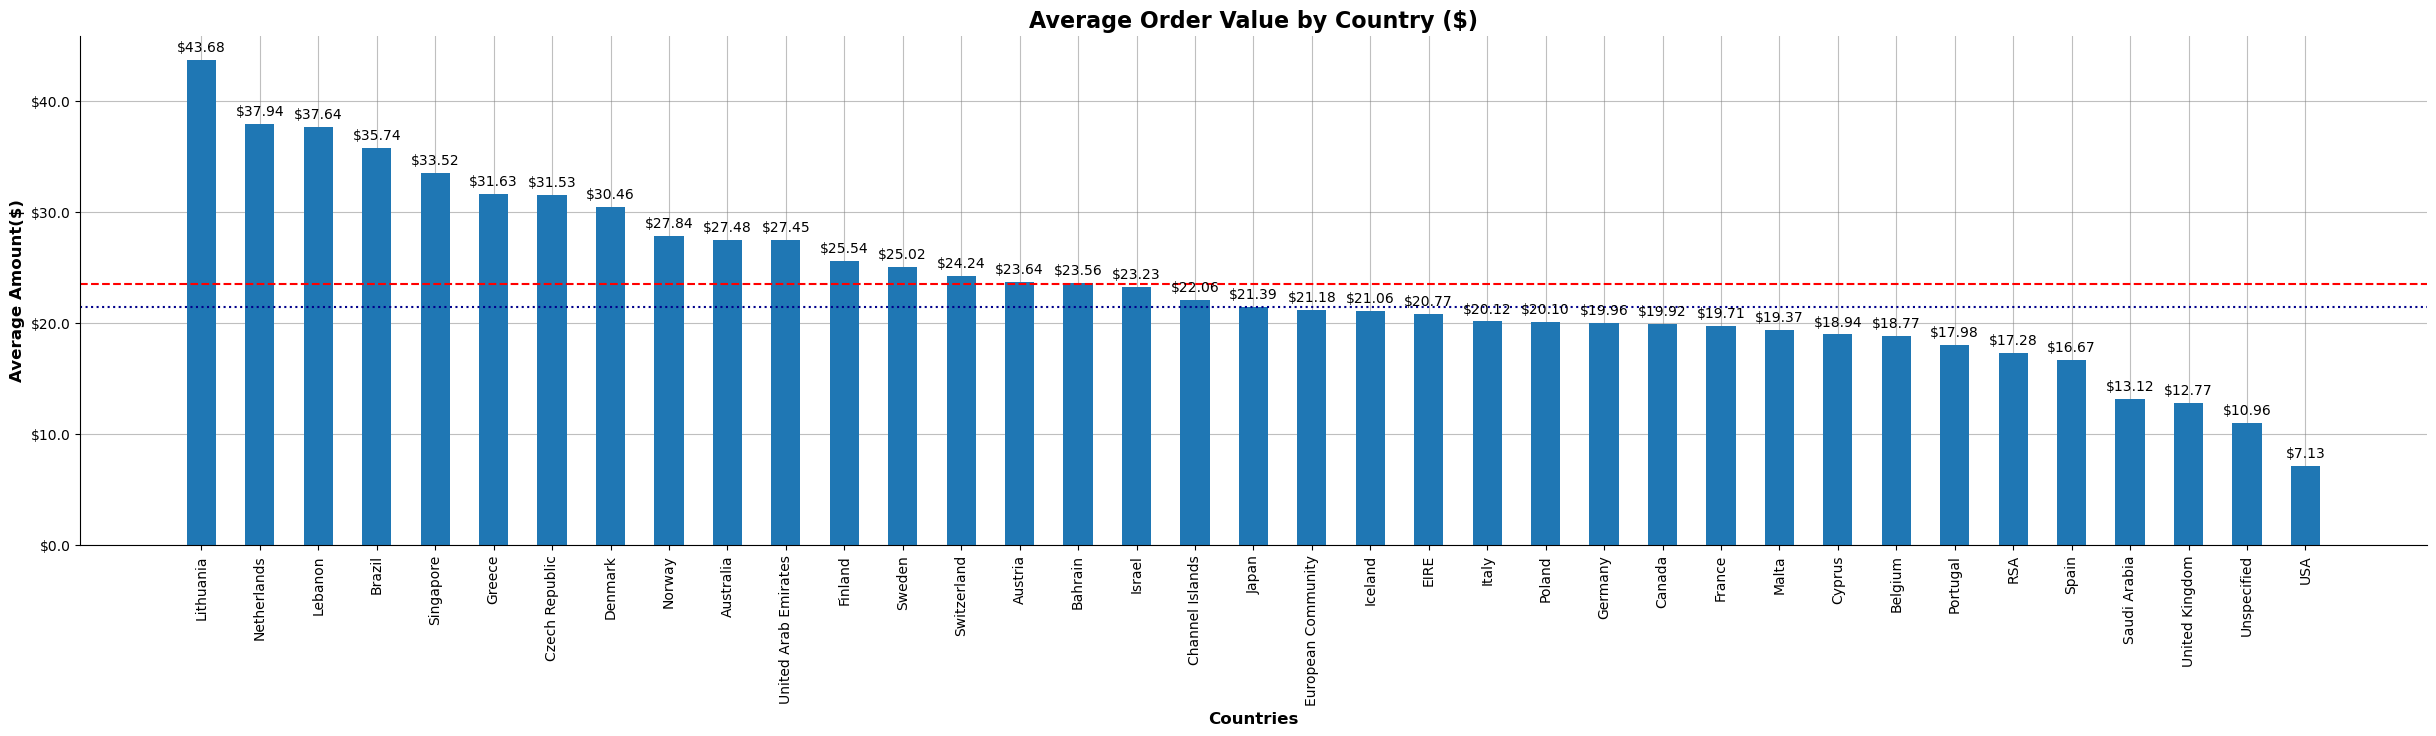

In [36]:
country_info = country_info.sort_values('avg_spend', ascending = False)
mean_val = country_info['avg_spend'].mean()
median_val = country_info['avg_spend'].median()

plt.figure(figsize = (25, 8))
ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)

b = plt.bar(country_info['Country'], country_info['avg_spend'], width = 0.5)
plt.title('Average Order Value by Country ($)', fontsize = 16, fontweight = 'bold')
plt.xlabel('Countries', fontsize = 12, fontweight = 'bold')
plt.ylabel('Average Amount($)', fontsize = 12, fontweight = 'bold')
plt.xticks(rotation = 90)
plt.bar_label(b, labels = [f'${v:,.2f}' for v in country_info['avg_spend']], padding = 4)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.1f}'))

plt.axhline(mean_val, color = 'red', linestyle = 'dashed', linewidth = 1.5, label = f'Mean: ${mean_val:.2f}')
plt.axhline(median_val, color = 'darkblue', linestyle = 'dotted', linewidth = 1.5, label = f'Median : ${median_val:.2f}')

plt.tight_layout(pad = 3.0)
plt.show()

* ***Lithuania** has the **highest average spend, USD 43.68**, indicating although **UK** produced highest revenue, but they **focused** more on **cheap products and more volume.***
* ***Netherlands, Lebanon, Brazil, Singapore, Greece, Czech Republic, Denmark, Norway, Australia, UAE, Finland, Sweden & Switzerland** have **higher average spend than mean**, indicating **great market growth potential.***
* ***USA** has the **least Average amount**, showing **less demand.***
* *The **rest** of the **countries** needs an **better market and demand studies** for **future growth.***

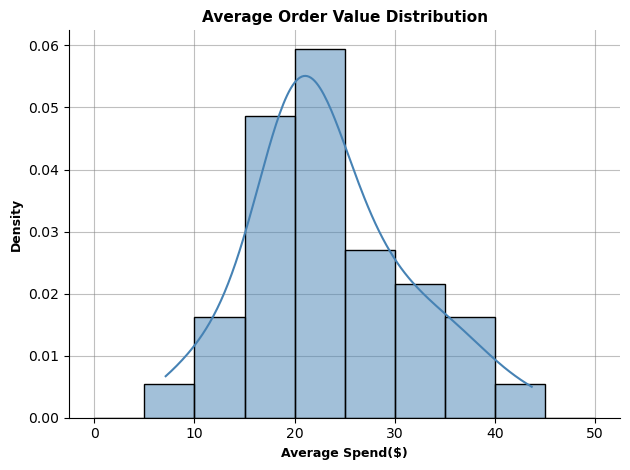

In [37]:
# Average spend distribution by country

# plt.figure(figsize = (6, 5))
ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)
sns.histplot(data = country_info, x = 'avg_spend', kde = True, stat = 'density', bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50], color = 'steelblue', alpha = 0.5)
plt.title('Average Order Value Distribution', fontsize = 11, fontweight = 'bold')
plt.xlabel('Average Spend($)', fontsize = 9, fontweight = 'bold')
plt.ylabel('Density', fontsize = 9, fontweight = 'bold')

plt.tight_layout()
plt.show()

***Most** of the countries **averagely spends** between **USD 20 - 25**.*

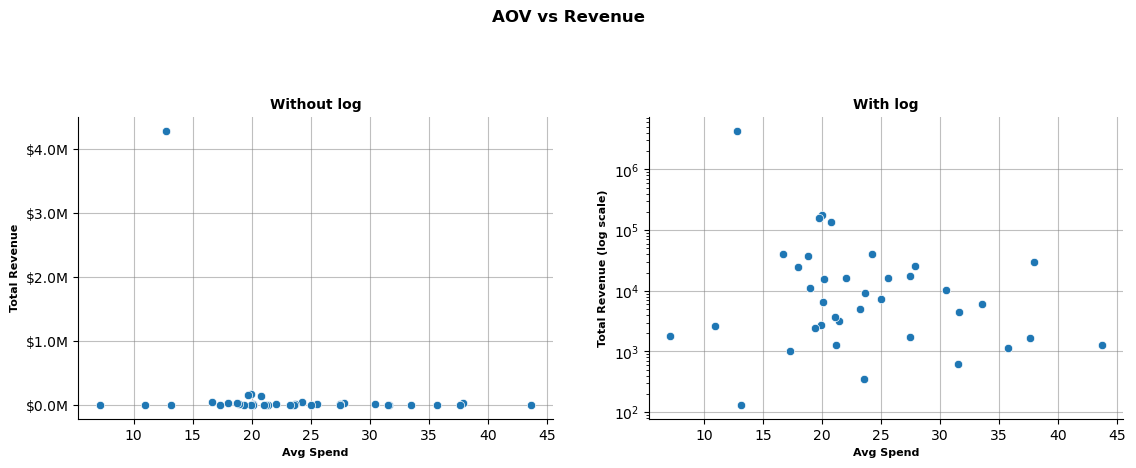

In [38]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

s1 = sns.scatterplot(data = country_info, x = 'avg_spend', y = 'total_rev', ax = ax[0])
ax[0].set_title('Without log', fontsize = 10, fontweight='bold')
ax[0].set_xlabel('Avg Spend', fontsize = 8, fontweight ='bold')
ax[0].set_ylabel('Total Revenue', fontsize = 8, fontweight ='bold')
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:,.1f}M'))


sns.scatterplot(data = country_info, x = 'avg_spend', y = 'total_rev', ax = ax[1])
ax[1].set_yscale('log')  
ax[1].set_title('With log', fontsize = 10, fontweight ='bold')
ax[1].set_xlabel('Avg Spend', fontsize = 8, fontweight ='bold')
ax[1].set_ylabel('Total Revenue (log scale)', fontsize = 8, fontweight ='bold')

plt.suptitle('AOV vs Revenue', fontsize = 12, fontweight = 'bold')
plt.tight_layout(pad = 3.0)
plt.show()

* ***No clear positive relationship between Average spend and Revenue.*** 
* ***High spenders ≠ high revenue countries.***

In [39]:
# Customer-wise Transaction Count & Total Spend

txn_info = temp.groupby('CustomerID').agg(total_txn = ('InvoiceNo', 'count'), 
                                         total_spend = ('TotalAmount', 'sum')).reset_index()

In [40]:
print(f'Total number of unique customers = {temp['InvoiceNo'].nunique():,}')

Total number of unique customers = 20,665


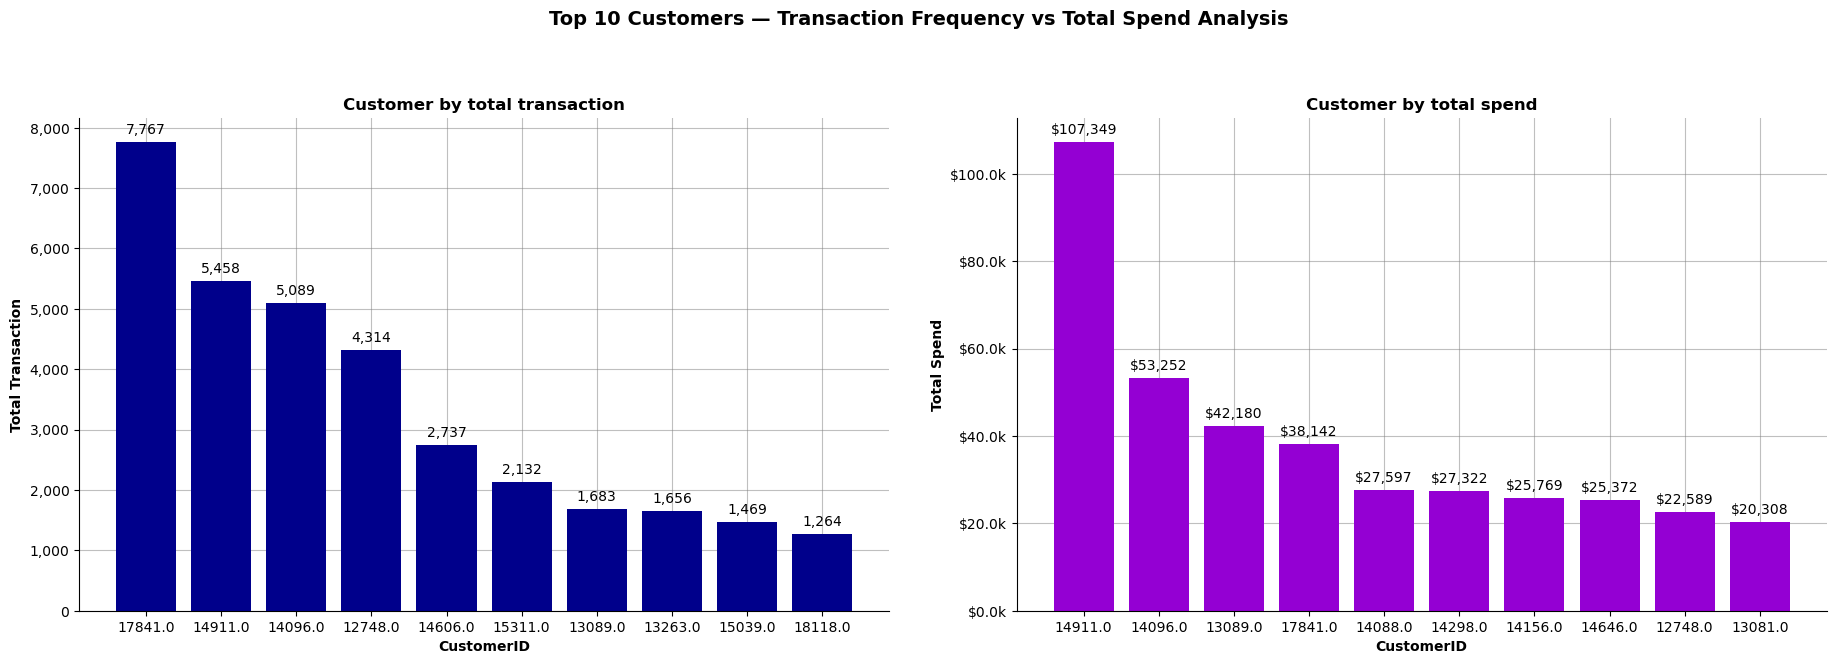

In [41]:
# top 10 most transaction vs most spend by customer

# Top 10 Customers by Transactions
top10_txn = txn_info.sort_values('total_txn', ascending = False).head(10)

# Top 10 Customers by Total Spend
top10_spend = txn_info.sort_values('total_spend', ascending = False).head(10)

fig, ax = plt.subplots(1, 2, figsize = (19, 7))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)


b0 = ax[0].bar(top10_txn['CustomerID'], top10_txn['total_txn'], color = 'darkblue')
ax[0].set_title('Customer by total transaction', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('CustomerID', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Total Transaction', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(b0, labels = [f'{v:,.0f}' for v in top10_txn['total_txn']], padding = 4, fontsize = 10)
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


b1 = ax[1].bar(top10_spend['CustomerID'], top10_spend['total_spend'], color = 'darkviolet')
ax[1].set_title('Customer by total spend', fontsize = 12, fontweight = 'bold')
ax[1].set_xlabel('CustomerID', fontsize = 10, fontweight = 'bold')
ax[1].set_ylabel('Total Spend', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(b1, labels = [f'${v:,.0f}' for v in top10_spend['total_spend']], padding = 4, fontsize = 10)
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.1f}k'))

plt.suptitle('Top 10 Customers — Transaction Frequency vs Total Spend Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout(pad = 3.0)
plt.show()

* ***CustomerID 17841.0 purchased** the **most with 7,767 transactions**, followed by **14911.0 and 14096.0** with **5,458 and 5,089 orders** respectively.*
* ***CustomerID 14911.0 spends** the most with **USD 107,349**, followed by **14096.0 and 13089.0** with **net spending of USD 53,252 and USD 42,180** respectively.*
* *This **indicates** that although **ID 17841.0 purchased the most** but focused in **less expensive products**, whereas **ID 14911.0** focused more on **expensive products.***
* *The **top 3 customers** in both graphs shows **their satisfaction and fullfilment**, indicates **they can be treated as premium customers and an additional discount** can be given to them.*

In [42]:
# orders cancelled information

cancelled_info = temp[temp['InvoiceNo'].str.contains('C')]
cancelled_info[['Quantity', 'TotalAmount']] = cancelled_info[['Quantity', 'TotalAmount']].abs()

In [43]:
# success orders information

success_info = temp[~temp['InvoiceNo'].str.contains('C')]

In [44]:
# Product-wise Units Sold & Revenue Generated

prod_info = success_info.groupby('Description').agg(Total_sold = ('Quantity', 'sum'), 
                                                    total_amt = ('TotalAmount', 'sum')).reset_index()

In [45]:
# Product-wise Units Cancelled & Revenue Lost

prod_info_cancel = cancelled_info.groupby('Description').agg(Total_cancel = ('Quantity', 'sum'), 
                                                             total_amt_lost = ('TotalAmount', 'sum')).reset_index()

In [46]:
print(f'Total number of unique products = {temp['Description'].nunique():,}')

Total number of unique products = 3,871


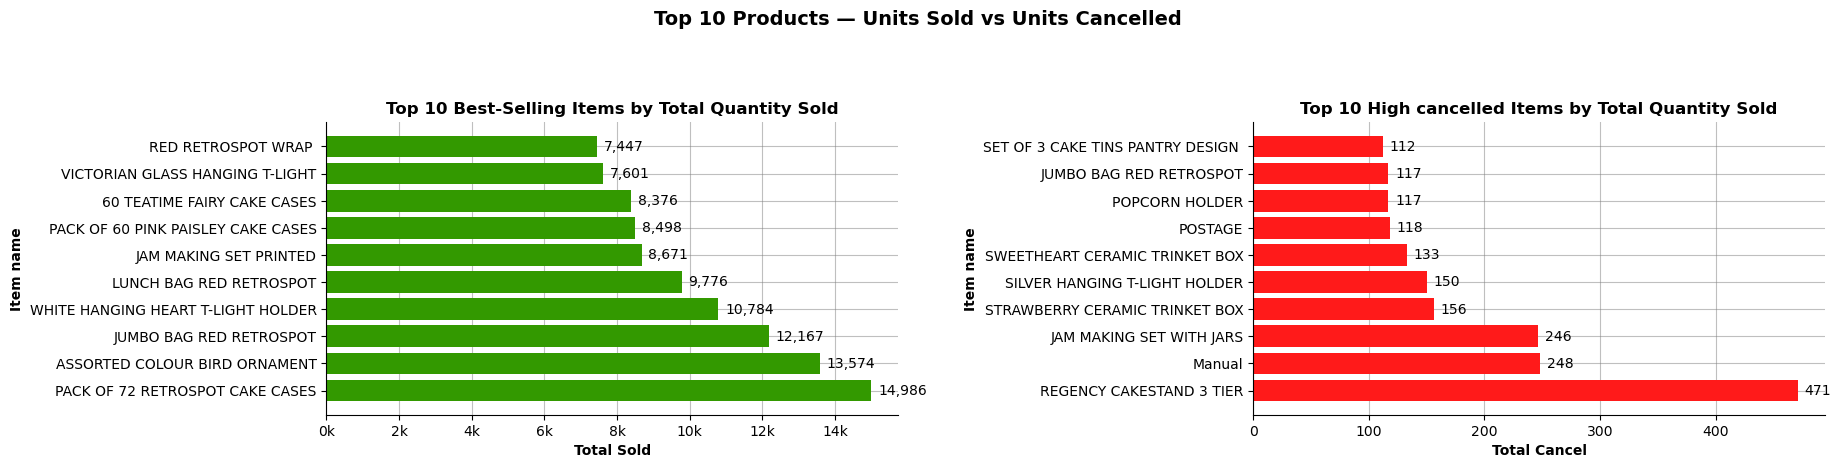

In [62]:
# Top selling vs Top cancelled products by quantity

# Top 10 Best-Selling Products by Quantity
top10_sold_items = prod_info.sort_values('Total_sold', ascending = False).head(10)

# Top 10 Most Cancelled Products by Quantity
top10_sold_items_cancel = prod_info_cancel.sort_values('Total_cancel', ascending = False).head(10)

fig, ax = plt.subplots(1, 2, figsize = (19, 5))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

bh1 = ax[0].barh(top10_sold_items['Description'], top10_sold_items['Total_sold'], color = '#339900')
ax[0].set_title('Top 10 Best-Selling Items by Total Quantity Sold', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Total Sold', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Item name', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(bh1, labels = [f'{v:,.0f}' for v in top10_sold_items['Total_sold']], padding = 5)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:,.0f}k'))


bh2 = ax[1].barh(top10_sold_items_cancel['Description'], top10_sold_items_cancel['Total_cancel'], color = '#ff1a1a')
ax[1].set_title('Top 10 High cancelled Items by Total Quantity Sold', fontsize = 12, fontweight = 'bold')
ax[1].set_xlabel('Total Cancel', fontsize = 10, fontweight = 'bold')
ax[1].set_ylabel('Item name', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(bh2, labels = [f'{v:,.0f}' for v in top10_sold_items_cancel['Total_cancel']], padding = 5)
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


plt.suptitle('Top 10 Products — Units Sold vs Units Cancelled', fontsize = 14, fontweight = 'bold')
plt.tight_layout(pad = 3.0)
plt.show()

***Best Selling Products***

* ***PACK OF 72 RETROSPOT CAKE CASES** dominates with **14,986 units** — nearly 2,000 units ahead of the second place.*
* ***ASSORTED COLOUR BIRD ORNAMENT** and **JUMBO BAG RED RETROSPOT** are strong runners up at **13,574** and **12,167 units**.*

***Most Cancelled Products***

* ***REGENCY CAKESTAND 3 TIER** is the most cancelled product with **471** cancellations — almost double the second place.*
* ***Manual** entries have high cancellations too, **248** — this is a data quality red flag, manual orders likely have errors leading to cancellations.*
* ***JAM MAKING SET WITH JARS** appears in both top cancelled **(246)** and was also visible in the top 10 best selling products — meaning it sells well but also gets cancelled a lot, worth investigating.*

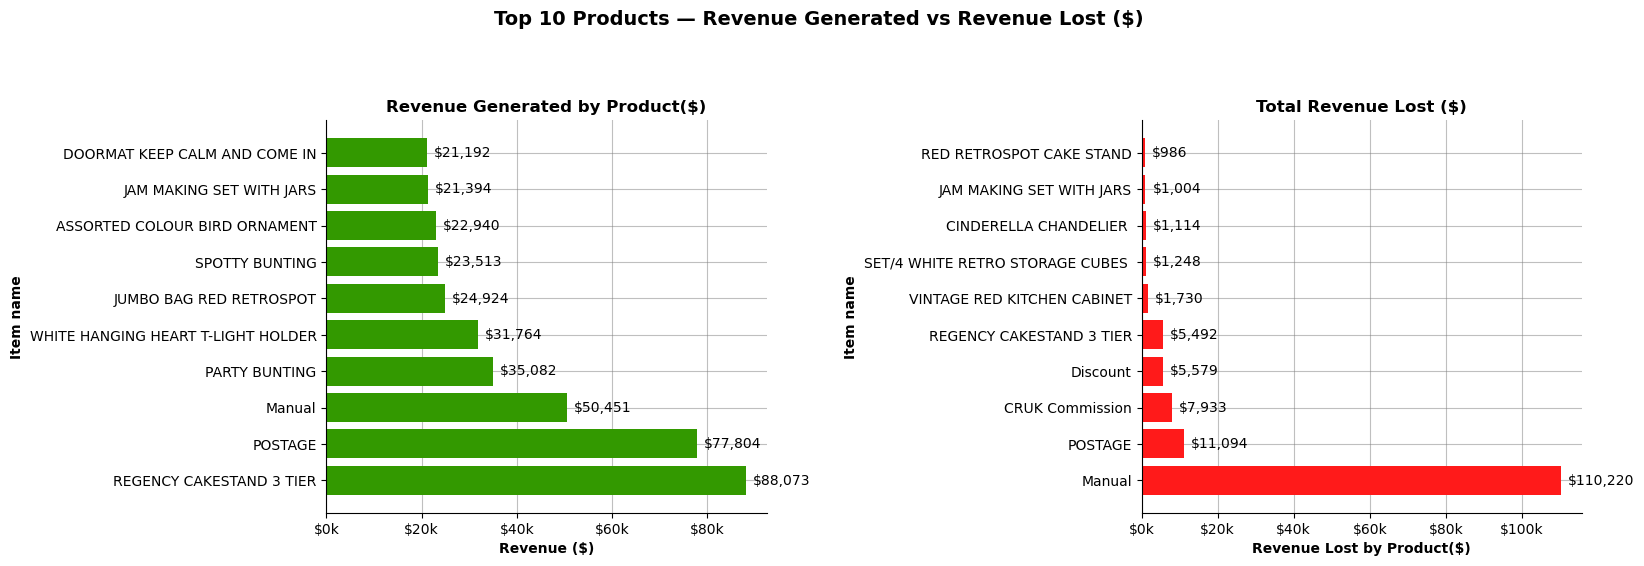

In [48]:

# Top 10 Products by Revenue Generated
top10_sold_items_amt = prod_info.sort_values('total_amt', ascending = False).head(10)

# Top 10 Products by Revenue Lost
top10_cancel_items_amt = prod_info_cancel.sort_values('total_amt_lost', ascending = False).head(10)
top10_sold_items_amt['rev_pct'] = 100*top10_sold_items_amt['total_amt']/top10_sold_items_amt['total_amt'].sum()

fig, ax = plt.subplots(1, 2, figsize = (17, 6))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

bh3 = ax[0].barh(top10_sold_items_amt['Description'], top10_sold_items_amt['total_amt'], color = '#339900')
ax[0].set_title('Revenue Generated by Product($)', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Revenue ($)', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Item name', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(bh3, labels = [f'${v:,.0f}' for v in top10_sold_items_amt['total_amt']], padding=5)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.0f}k'))

bh4 = ax[1].barh(top10_cancel_items_amt['Description'], top10_cancel_items_amt['total_amt_lost'], color = '#ff1a1a')
ax[1].set_title('Total Revenue Lost ($)', fontsize = 12, fontweight = 'bold')
ax[1].set_xlabel('Revenue Lost by Product($)', fontsize = 10, fontweight = 'bold')
ax[1].set_ylabel('Item name', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(bh4, labels = [f'${v:,.0f}' for v in top10_cancel_items_amt['total_amt_lost']], padding = 5)
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.0f}k'))

plt.suptitle('Top 10 Products — Revenue Generated vs Revenue Lost ($)', fontsize = 14, fontweight = 'bold')
plt.tight_layout(pad = 3.0)
plt.show()

***Revenue Generated***

* ***REGENCY CAKESTAND 3 TIER** leads with  **USD 88,073.20**, far ahead of everyone else.*
* ***POSTAGE** being **2nd** highest, **USD 77,803.96**.*
* ***Manual** entries at **3rd** place, **USD 50,451.38**.*

***Revenue Lost***

* ***Manual** cause the most revenue loss by far at **USD 105,000** — this is massive and actually exceeds any single product's revenue. This strongly suggests manual orders are error-prone and need a proper process fix.*
* ***POSTAGE** cancellations are also high **USD 15k** lost — customers cancelling orders and getting shipping refunded.*
* ***CRUK Commission**, **Discount** appearing here are doesn't seems real products — these are internal accounting entries leaking into the dataset.*

In [49]:
print(f'The total revenue after cancellation = ${success_info['TotalAmount'].sum():,.2f}')
print(f'Total number of purchased items = {success_info['Quantity'].sum():,}')
print(f'Total number of successful transactions = {success_info.shape[0]:,}')

The total revenue after cancellation = $5,326,594.35
Total number of purchased items = 2,604,497
Total number of successful transactions = 367,107


In [50]:
temp.to_csv('Cleaned_data.csv', index = False)
country_info.to_csv('country_data.csv', index = False)
txn_info.to_csv('txn_info.csv', index = False)
success_info.to_csv('success_info.csv', index = False)
cancelled_info.to_csv('cancelled_info.csv', index = False)
prod_info.to_csv('prod_info.csv', index = False)
prod_info_cancel.to_csv('prod_info_cancel.csv', index = False)